In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st

In [2]:
working_dir = %pwd
print(working_dir)

folder_path = f"{working_dir}\data" 
print(folder_path)

file_path = os.path.join(folder_path, "Online Sales Data.csv")
print(file_path)

df = pd.read_csv(file_path)
df.head()

C:\Users\Home\dev streamlit dataAnalysis\priv-streamlit-PreAnalysisWeb
C:\Users\Home\dev streamlit dataAnalysis\priv-streamlit-PreAnalysisWeb\data
C:\Users\Home\dev streamlit dataAnalysis\priv-streamlit-PreAnalysisWeb\data\Online Sales Data.csv


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [3]:
df2 = pd.DataFrame(df)
print(df2.dtypes)

Transaction ID        int64
Date                 object
Product Category     object
Product Name         object
Units Sold            int64
Unit Price          float64
Total Revenue       float64
Region               object
Payment Method       object
dtype: object


In [4]:
df['Date'] = df['Date'].astype("datetime64[ns]")

print(df.dtypes)
df.head()

Transaction ID               int64
Date                datetime64[ns]
Product Category            object
Product Name                object
Units Sold                   int64
Unit Price                 float64
Total Revenue              float64
Region                      object
Payment Method              object
dtype: object


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


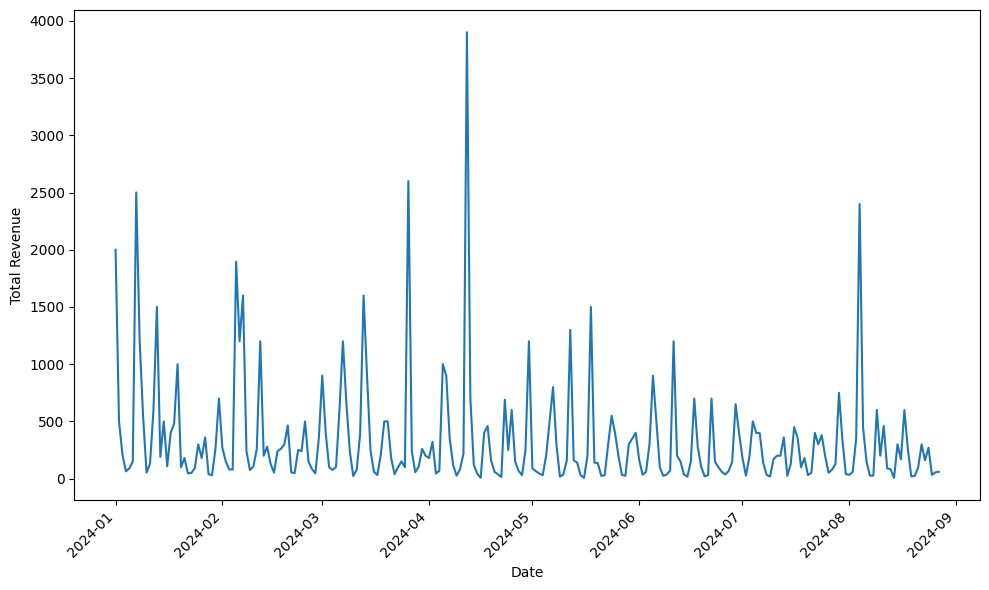

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 6)) # increase figure size to allow more space

x_axis = 'Date'
y_axis = 'Total Revenue'

sns.lineplot(x=df[x_axis], y=df[y_axis], ax=ax)

# Format the x-axis dates
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # or '%b %d, %Y' or other formats

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right') # ha = horizontal alignment

plt.tight_layout() # Adjust layout to prevent clipping of labels
plt.show()

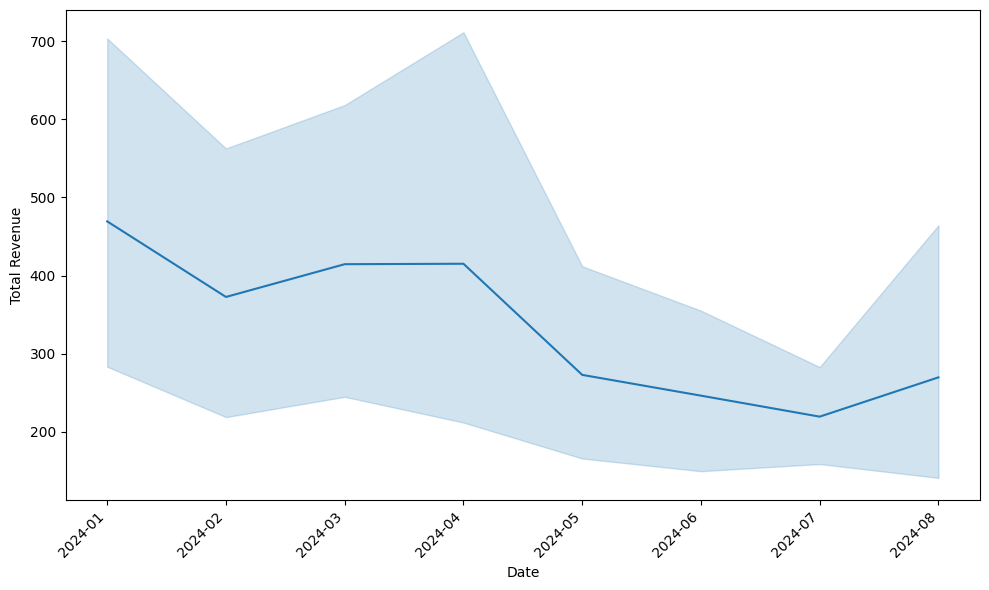

In [7]:
fig, ax = plt.subplots(figsize=(10, 6)) # increase figure size to allow more space

df[x_axis] = pd.to_datetime(df[x_axis], errors='coerce')

# Convert datetime column to YYYY-MM format (string)
df[x_axis] = df[x_axis].dt.strftime('%Y-%m')
sns.lineplot(x=df[x_axis], y=df[y_axis], ax=ax)

# Format the x-axis dates
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right') # ha = horizontal alignment

plt.tight_layout() # Adjust layout to prevent clipping of labels

plt.show()

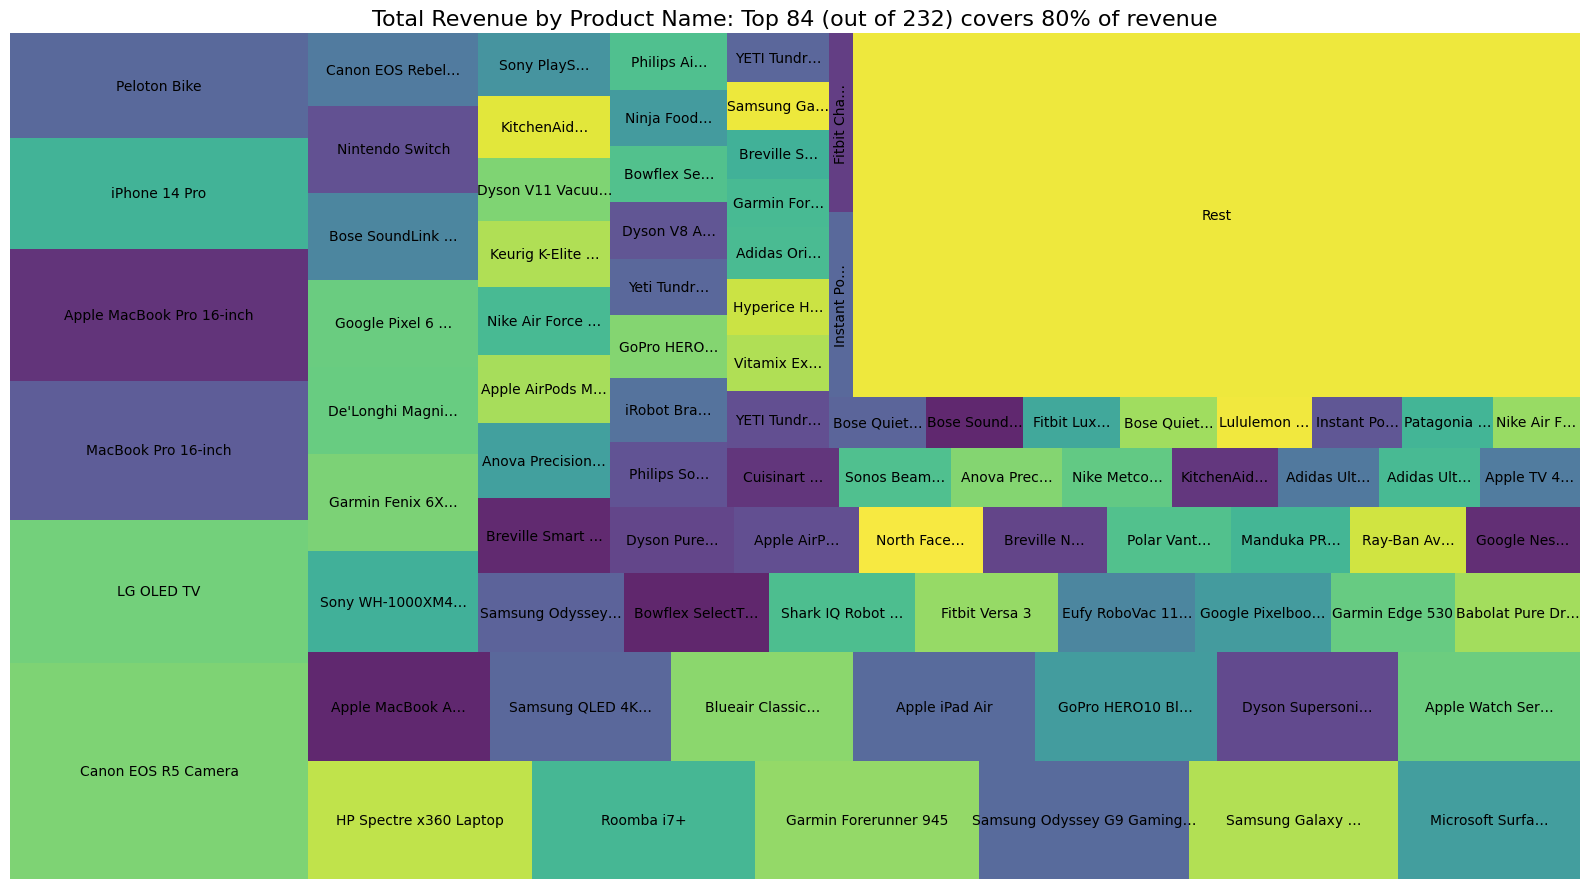

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify

# --- controls ---
PARETO_SHARE = 0.80                 # target share of revenue (Pareto)
MAX_CATEGORIES = 85                 # hard cap: never show more than 85 products (excluding Rest)

# label-length tiers (by rank within the selected top set)
TOP_N1 = 10
TOP_N2 = 40
CHARS_TOP1 = 25
CHARS_TOP2 = 15
CHARS_REST = 10

# rotate labels ONLY for very narrow rectangles
ROTATE_IF_WIDTH_BELOW = 5.0         # tweak: 4.0 fewer rotations, 6.0 more

# 1) Aggregate revenue by product
agg_df = (
    df.groupby("Product Name", as_index=False)["Total Revenue"]
      .sum()
      .sort_values("Total Revenue", ascending=False)
      .reset_index(drop=True)
)

total_rev = agg_df["Total Revenue"].sum()
distinct_products = agg_df["Product Name"].nunique()

# 2) Pareto selection: products needed to reach 80% revenue, but capped at MAX_CATEGORIES
agg_df["cum_share"] = agg_df["Total Revenue"].cumsum() / total_rev
k = int((agg_df["cum_share"] < PARETO_SHARE).sum() + 1)  # include the first row that crosses 80%
top_n = min(k, MAX_CATEGORIES)

top_df = agg_df.head(top_n)[["Product Name", "Total Revenue"]]
rest_revenue = agg_df.iloc[top_n:]["Total Revenue"].sum()

# ✅ Actual coverage based on the selected/capped Top N (NOT the target)
coverage_pct = round((top_df["Total Revenue"].sum() / total_rev) * 100)

# 3) Build treemap df (Top dynamic + Rest)
treemap_df = pd.concat(
    [
        top_df,
        pd.DataFrame([{"Product Name": "Rest", "Total Revenue": rest_revenue}]),
    ],
    ignore_index=True
)

# 4) Dynamic label truncation by rank
def trunc(s: str, n: int) -> str:
    return (s[:n] + "…") if len(s) > n else s

labels = []
for i, name in enumerate(treemap_df["Product Name"]):
    if name == "Rest":
        labels.append("Rest")
    elif i < TOP_N1:
        labels.append(trunc(name, CHARS_TOP1))
    elif i < TOP_N2:
        labels.append(trunc(name, CHARS_TOP2))
    else:
        labels.append(trunc(name, CHARS_REST))

# 5) Plot with squarify.plot to preserve layout/colors, but suppress labels
plt.figure(figsize=(16, 9))
ax = plt.gca()

squarify.plot(
    sizes=treemap_df["Total Revenue"],
    label=None,  # we'll draw labels ourselves with dynamic rotation
    alpha=0.85,
    ax=ax
)

# 6) Overlay labels with dynamic rotation (layout unchanged)
sizes = treemap_df["Total Revenue"].tolist()
norm_sizes = squarify.normalize_sizes(sizes, 100, 100)
rects = squarify.squarify(norm_sizes, 0, 0, 100, 100)

for i, r in enumerate(rects):
    x, y, dx, dy = r["x"], r["y"], r["dx"], r["dy"]
    rotate = (labels[i] != "Rest" and dx < ROTATE_IF_WIDTH_BELOW)

    ax.text(
        x + dx / 2,
        y + dy / 2,
        labels[i],
        ha="center",
        va="center",
        rotation=90 if rotate else 0,
        fontsize=10,
        clip_on=True
    )

# Title:(Top N is capped at 85)
distinct_products = agg_df["Product Name"].nunique()

plt.title(
    f"Total Revenue by Product Name: "
    f"Top {top_n} (out of {distinct_products}) covers {revenue_coverage_pct}% of revenue",
    fontsize=16
)

plt.axis("off")
plt.tight_layout()
plt.show()
